# Graph Neural Network — Bicep Curl Form Classification
### PyTorch Geometric (PyG) — Full End-to-End Trained GNN

This notebook trains a **proper GNN** where the graph convolutional weights are learned via backpropagation — not randomly initialized.

**Architecture:** 2-layer GCN → Global Mean Pooling → MLP head → Binary classifier

**Labels:** `C` = Correct form | `L` = Lean-back error

---
### Setup (run once)
```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
pip install torch_geometric
pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
```
Or use **Google Colab** — PyG is pre-available via:
```bash
!pip install torch_geometric
```

## 1. Imports

In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, global_max_pool
from torch_geometric.utils import to_networkx

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# ── Config ─────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PALETTE = ['#667eea', '#764ba2']

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
})

print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')
print(f'CUDA     : {torch.cuda.is_available()}')

PyTorch  : 2.10.0+cu128
Device   : cuda
CUDA     : True


## 2. Load & Split Data

In [3]:
# ── Load ───────────────────────────────────────────────────────────────────
# Replace paths with your actual train.csv and test.csv
# If you only have train.csv, the cell below splits it for you

# df = pd.read_csv('train.csv')

# ── If you have a separate test.csv, load it here and skip the split ──────
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

# # ── Otherwise, split train.csv into train / test ──────────────────────────
# train_df, test_df = train_test_split(
#     df, test_size=0.2, random_state=RANDOM_STATE, stratify=df['label']
# )
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train : {len(train_df):,} samples')
print(f'Test  : {len(test_df):,} samples')
print(f'\nTrain label counts:\n{train_df["label"].value_counts()}')
print(f'\nTest label counts:\n{test_df["label"].value_counts()}')

Train : 15,372 samples
Test  : 604 samples

Train label counts:
label
C    8238
L    7134
Name: count, dtype: int64

Test label counts:
label
C    339
L    265
Name: count, dtype: int64


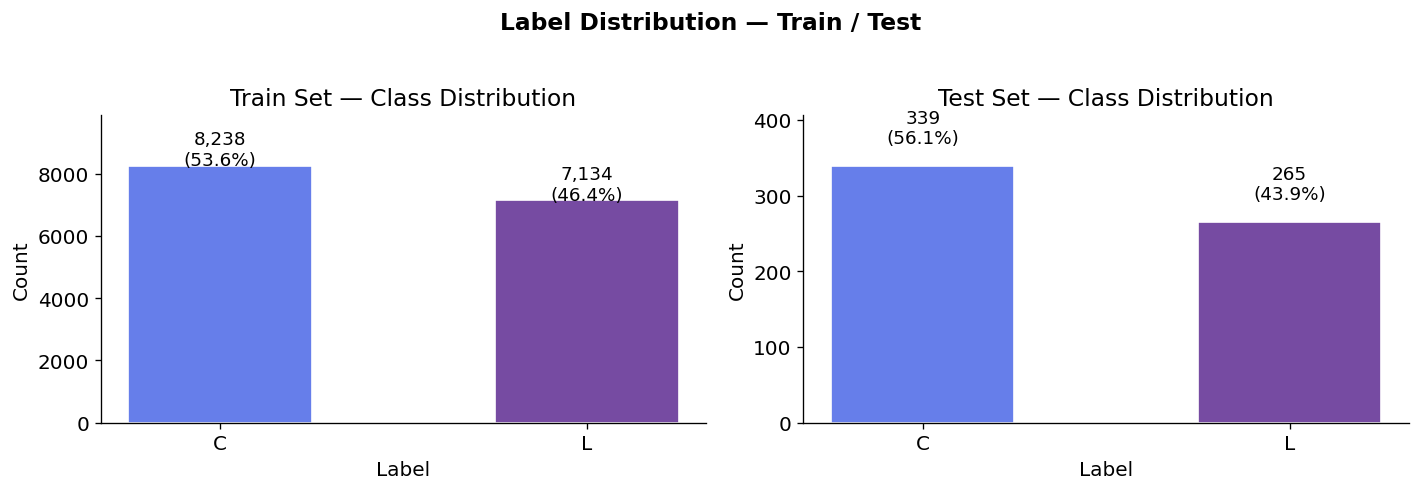

In [4]:
# ── Class distribution plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (df_plot, title) in zip(axes, [(train_df, 'Train Set'), (test_df, 'Test Set')]):
    counts = df_plot['label'].value_counts()
    bars = ax.bar(counts.index, counts.values, color=PALETTE, edgecolor='white', width=0.5)
    ax.set_title(f'{title} — Class Distribution')
    ax.set_xlabel('Label'); ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{val:,}\n({val/len(df_plot)*100:.1f}%)', ha='center', fontsize=11)
    ax.set_ylim(0, counts.max() * 1.2)
plt.suptitle('Label Distribution — Train / Test', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_01_class_distribution.png', bbox_inches='tight')
plt.show()

## 3. Define the Pose Graph

Each frame → a graph where:
- **Nodes** = 9 body landmarks
- **Edges** = anatomical kinematic connections
- **Node features** = `[x, y, z, visibility]`

In [5]:
# ═══════════════════════════════════════════════════════════════
# CORRECTED GNN — PoseGCN with flatten instead of mean pooling
# ═══════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.data import Data, DataLoader

# ── Constants matching the SOURCE CODE exactly ────────────────
# Landmark order taken directly from bicep_curl.py init_important_landmarks()
LANDMARKS = [
    'nose',
    'left_shoulder',  'right_shoulder',
    'right_elbow',    'left_elbow',     # RIGHT before LEFT — matches source
    'right_wrist',    'left_wrist',     # RIGHT before LEFT — matches source
    'left_hip',       'right_hip',
]
N_NODES = len(LANDMARKS)   # 9
N_FEATS = 4                # x, y, z, visibility

# Anatomical edges — wired correctly to the above order
node_to_idx = {n: i for i, n in enumerate(LANDMARKS)}
SKELETON_EDGES = [
    ('nose',          'left_shoulder'),
    ('nose',          'right_shoulder'),
    ('left_shoulder', 'right_shoulder'),
    ('left_shoulder', 'left_elbow'),
    ('right_shoulder','right_elbow'),
    ('left_elbow',    'left_wrist'),
    ('right_elbow',   'right_wrist'),
    ('left_shoulder', 'left_hip'),
    ('right_shoulder','right_hip'),
    ('left_hip',      'right_hip'),
]

src, dst = [], []
for u, v in SKELETON_EDGES:
    i, j = node_to_idx[u], node_to_idx[v]
    src += [i, j]
    dst += [j, i]
EDGE_INDEX = torch.tensor([src, dst], dtype=torch.long)

print('Nodes:', N_NODES, '| Edges (directed):', EDGE_INDEX.shape[1])
print('Landmark → index mapping:')
for name, idx in node_to_idx.items():
    print(f'  {idx}: {name}')


Nodes: 9 | Edges (directed): 20
Landmark → index mapping:
  0: nose
  1: left_shoulder
  2: right_shoulder
  3: right_elbow
  4: left_elbow
  5: right_wrist
  6: left_wrist
  7: left_hip
  8: right_hip


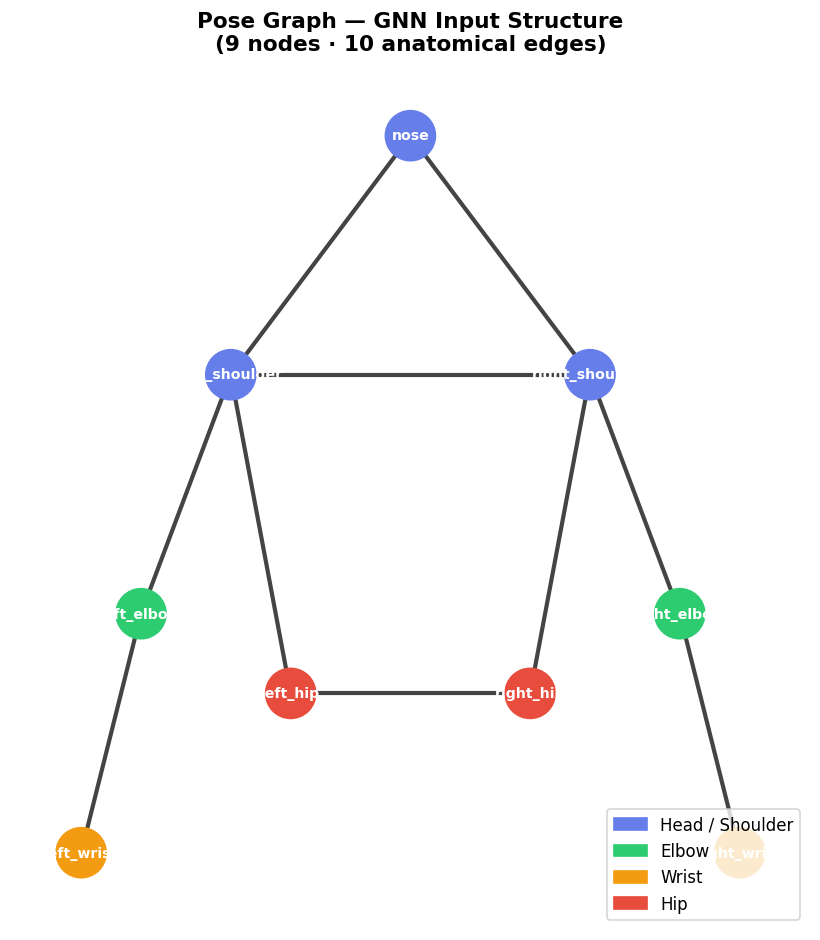

In [6]:
# ── Visualise the skeleton graph ───────────────────────────────────────────
G = nx.Graph()
G.add_nodes_from(LANDMARKS)
G.add_edges_from(SKELETON_EDGES)

pos = {
    'nose':           ( 0.0,  1.8),
    'left_shoulder':  (-0.6,  1.2),
    'right_shoulder': ( 0.6,  1.2),
    'left_elbow':     (-0.9,  0.6),
    'right_elbow':    ( 0.9,  0.6),
    'left_wrist':     (-1.1,  0.0),
    'right_wrist':    ( 1.1,  0.0),
    'left_hip':       (-0.4,  0.4),
    'right_hip':      ( 0.4,  0.4),
}
node_colors = [
    '#e74c3c' if 'hip' in n else
    '#f39c12' if 'wrist' in n else
    '#2ecc71' if 'elbow' in n else
    '#667eea'
    for n in LANDMARKS
]

fig, ax = plt.subplots(figsize=(7, 8))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=900, ax=ax)
nx.draw_networkx_edges(G, pos, width=2.5, edge_color='#444', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8.5, font_color='white', font_weight='bold', ax=ax)
legend_items = [
    mpatches.Patch(color='#667eea', label='Head / Shoulder'),
    mpatches.Patch(color='#2ecc71', label='Elbow'),
    mpatches.Patch(color='#f39c12', label='Wrist'),
    mpatches.Patch(color='#e74c3c', label='Hip'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=10)
ax.set_title('Pose Graph — GNN Input Structure\n(9 nodes · 10 anatomical edges)', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig_02_pose_graph.png', bbox_inches='tight')
plt.show()

## 4. Standardise Features — Train & Test Separately

**Rule:** Scaler is `fit` only on train. Test is only `transform`-ed.  
This prevents data leakage.

In [7]:
# ── Normalise + Standardise (camera-invariant) ────────────────────────────

LANDMARKS = [
    'nose',
    'left_shoulder',  'right_shoulder',
    'right_elbow',    'left_elbow',       # ← matches CSV: right_elbow is col 3
    'right_wrist',    'left_wrist',       # ← matches CSV: right_wrist is col 5
    'left_hip',       'right_hip',
]
def normalize_pose(df):
    """
    Make coordinates camera-invariant:
    1. Subtract torso centre  → removes camera position offset
    2. Divide by torso size   → removes camera distance / person height
    """
    df = df.copy()

    centre_x = (df['left_shoulder_x'] + df['right_shoulder_x'] +
                 df['left_hip_x']      + df['right_hip_x']) / 4
    centre_y = (df['left_shoulder_y'] + df['right_shoulder_y'] +
                 df['left_hip_y']      + df['right_hip_y']) / 4

    shoulder_mid_x = (df['left_shoulder_x'] + df['right_shoulder_x']) / 2
    shoulder_mid_y = (df['left_shoulder_y'] + df['right_shoulder_y']) / 2
    hip_mid_x      = (df['left_hip_x']      + df['right_hip_x'])      / 2
    hip_mid_y      = (df['left_hip_y']      + df['right_hip_y'])      / 2

    torso_size = np.sqrt(
        (shoulder_mid_x - hip_mid_x) ** 2 +
        (shoulder_mid_y - hip_mid_y) ** 2
    ) + 1e-6

    for lm in LANDMARKS:
        df[f'{lm}_x'] = (df[f'{lm}_x'] - centre_x) / torso_size
        df[f'{lm}_y'] = (df[f'{lm}_y'] - centre_y) / torso_size
        df[f'{lm}_z'] =  df[f'{lm}_z']              / torso_size
        # visibility left as-is

    return df


# Apply normalisation BEFORE scaling
train_norm = normalize_pose(train_df)
test_norm  = normalize_pose(test_df)

# Encode labels
le = LabelEncoder()
y_train_np = le.fit_transform(train_norm['label'].values)
y_test_np  = le.transform(test_norm['label'].values)
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# Standardise SEPARATELY — scaler fit on train only
FEATURE_COLS = [c for c in train_norm.columns if c != 'label']
scaler = StandardScaler()
X_train_np = scaler.fit_transform(train_norm[FEATURE_COLS].values)
X_test_np  = scaler.transform(test_norm[FEATURE_COLS].values)

print(f'\nTrain — mean: {X_train_np.mean():+.5f} | std: {X_train_np.std():.5f}')
print(f'Test  — mean: {X_test_np.mean():+.5f} | std: {X_test_np.std():.5f}')

Label encoding: {'C': np.int64(0), 'L': np.int64(1)}

Train — mean: -0.00000 | std: 1.00000
Test  — mean: -0.12480 | std: 1.43005


## 5. Build PyG Dataset

Each row → a `torch_geometric.data.Data` object:
- `x`          : node feature matrix `[9, 4]`
- `edge_index` : `[2, 20]` (10 undirected edges × 2 directions)
- `y`          : scalar label `{0, 1}`

## 6. Define the GNN Model

Architecture:
```
Input node features [9, 4]
    ↓
GCNConv(4  → 64)  + BatchNorm + ReLU + Dropout
    ↓  (message passing over skeleton edges)
GCNConv(64 → 128) + BatchNorm + ReLU + Dropout
    ↓  (message passing over skeleton edges)
GCNConv(128→ 64)  + BatchNorm + ReLU
    ↓
Global Mean Pooling  [graph-level embedding: 64]
    ↓
Linear(64 → 32) + ReLU + Dropout
Linear(32 → 2)          ← logits
```

All weights are **jointly trained** via backpropagation through the entire graph.

## 7. Train the GNN

In [8]:
# ═══════════════════════════════════════════════════════════════
# CORRECTED GNN — PoseGCN with flatten instead of mean pooling
# ═══════════════════════════════════════════════════════════════


# ── Dataset builder ───────────────────────────────────────────
def build_graph_dataset(X_np, y_np, edge_index):
    dataset = []
    for i in range(len(X_np)):
        x = torch.tensor(
            X_np[i].reshape(N_NODES, N_FEATS),
            dtype=torch.float
        )
        y = torch.tensor(y_np[i], dtype=torch.long)
        dataset.append(Data(x=x, edge_index=edge_index, y=y))
    return dataset

train_dataset = build_graph_dataset(X_train_np, y_train_np, EDGE_INDEX)
test_dataset  = build_graph_dataset(X_test_np,  y_test_np,  EDGE_INDEX)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

sample = train_dataset[0]
print(f'\nSample: x={sample.x.shape} | edge_index={sample.edge_index.shape} | y={sample.y}')


# ── Model: PoseGCN with FLATTEN (not mean pool) ───────────────
class PoseGCN(nn.Module):
    """
    3-layer GCN.
    Key fix: instead of global_mean_pool which destroys node identity,
    we flatten all node embeddings -> [batch, N_NODES * out_feats].
    This preserves WHICH joint has WHICH embedding.
    """
    def __init__(self, in_feats=4, hidden=64, out_feats=32,
                 n_classes=2, dropout=0.4):
        super().__init__()
        self.out_feats = out_feats

        self.conv1 = GCNConv(in_feats,  hidden)
        self.conv2 = GCNConv(hidden,    hidden)
        self.conv3 = GCNConv(hidden,    out_feats)

        self.bn1 = nn.BatchNorm1d(hidden)
        self.bn2 = nn.BatchNorm1d(hidden)
        self.bn3 = nn.BatchNorm1d(out_feats)

        # Input = 9 nodes × out_feats = 9 × 32 = 288
        self.head = nn.Sequential(
            nn.Linear(N_NODES * out_feats, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )
        self.dropout = dropout

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # GCN message passing
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn3(self.conv3(x, edge_index)))

        # ✅ FLATTEN — preserves all 9 node embeddings separately
        # x shape: [total_nodes_in_batch, out_feats]
        # After view: [batch_size, N_NODES * out_feats]
        batch_size = batch.max().item() + 1
        x = x.view(batch_size, N_NODES * self.out_feats)

        return self.head(x)

    def embed(self, data):
        """Return flattened node embeddings before classification head."""
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        batch_size = batch.max().item() + 1
        return x.view(batch_size, N_NODES * self.out_feats)


# ── Model: PoseGAT with FLATTEN ───────────────────────────────
class PoseGAT(nn.Module):
    def __init__(self, in_feats=4, hidden=32, out_feats=16,
                 n_classes=2, heads=4, dropout=0.4):
        super().__init__()
        self.out_feats = out_feats

        self.conv1 = GATConv(in_feats,       hidden,     heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden * heads, hidden,     heads=heads, dropout=dropout)
        self.conv3 = GATConv(hidden * heads, out_feats,  heads=1, concat=False, dropout=dropout)

        self.bn1 = nn.BatchNorm1d(hidden * heads)
        self.bn2 = nn.BatchNorm1d(hidden * heads)
        self.bn3 = nn.BatchNorm1d(out_feats)

        # 9 × 16 = 144
        self.head = nn.Sequential(
            nn.Linear(N_NODES * out_feats, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )
        self.dropout = dropout

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.bn3(self.conv3(x, edge_index)))

        batch_size = batch.max().item() + 1
        x = x.view(batch_size, N_NODES * self.out_feats)
        return self.head(x)


# ── Training utilities ────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out  = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        correct    += (out.argmax(1) == batch.y).sum().item()
        total      += batch.num_graphs
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_probs, all_labels = [], [], []
    for batch in loader:
        batch  = batch.to(device)
        out    = model(batch)
        loss   = criterion(out, batch.y)
        total_loss += loss.item() * batch.num_graphs
        probs  = F.softmax(out, dim=1)[:, 1]
        pred   = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total   += batch.num_graphs
        all_preds.extend(pred.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_probs), np.array(all_labels))


def train_model(model, train_loader, test_loader, name, epochs=100):
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_acc, best_state = 0.0, None

    print(f'Training {name} on {DEVICE}...')
    print(f'{"Epoch":>6} {"TrainLoss":>10} {"ValLoss":>10} {"TrainAcc":>10} {"ValAcc":>10}')
    print('-' * 55)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        va_loss, va_acc, _, _, _ = evaluate(model, test_loader, criterion, DEVICE)
        scheduler.step(va_loss)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        if va_acc > best_acc:
            best_acc  = va_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1:
            print(f'{epoch:>6} {tr_loss:>10.4f} {va_loss:>10.4f} '
                  f'{tr_acc*100:>9.2f}% {va_acc*100:>9.2f}%')

    model.load_state_dict(best_state)
    print(f'\nBest val accuracy: {best_acc*100:.2f}%')
    return history


# ── Train ─────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

gcn_model = PoseGCN().to(DEVICE)
gcn_history = train_model(gcn_model, train_loader, test_loader, 'GCN')

# gat_model = PoseGAT().to(DEVICE)
# gat_history = train_model(gat_model, train_loader, test_loader, 'GAT')


Sample: x=torch.Size([9, 4]) | edge_index=torch.Size([2, 20]) | y=0
Training GCN on cuda...
 Epoch  TrainLoss    ValLoss   TrainAcc     ValAcc
-------------------------------------------------------
     1     0.3953     0.2542     81.95%     92.22%
    10     0.0579     0.0879     98.29%     96.52%
    20     0.0479     0.1735     98.69%     96.03%
    30     0.0371     0.0348     99.02%     98.34%
    40     0.0393     0.0373     98.95%     98.51%
    50     0.0333     0.0378     99.02%     98.34%
    60     0.0307     0.0709     99.15%     97.68%
    70     0.0297     0.0915     99.15%     97.68%
    80     0.0285     0.0713     99.22%     97.68%
    90     0.0279     0.0610     99.12%     97.85%
   100     0.0290     0.0652     99.17%     97.85%

Best val accuracy: 99.50%


## 8. Training Curves

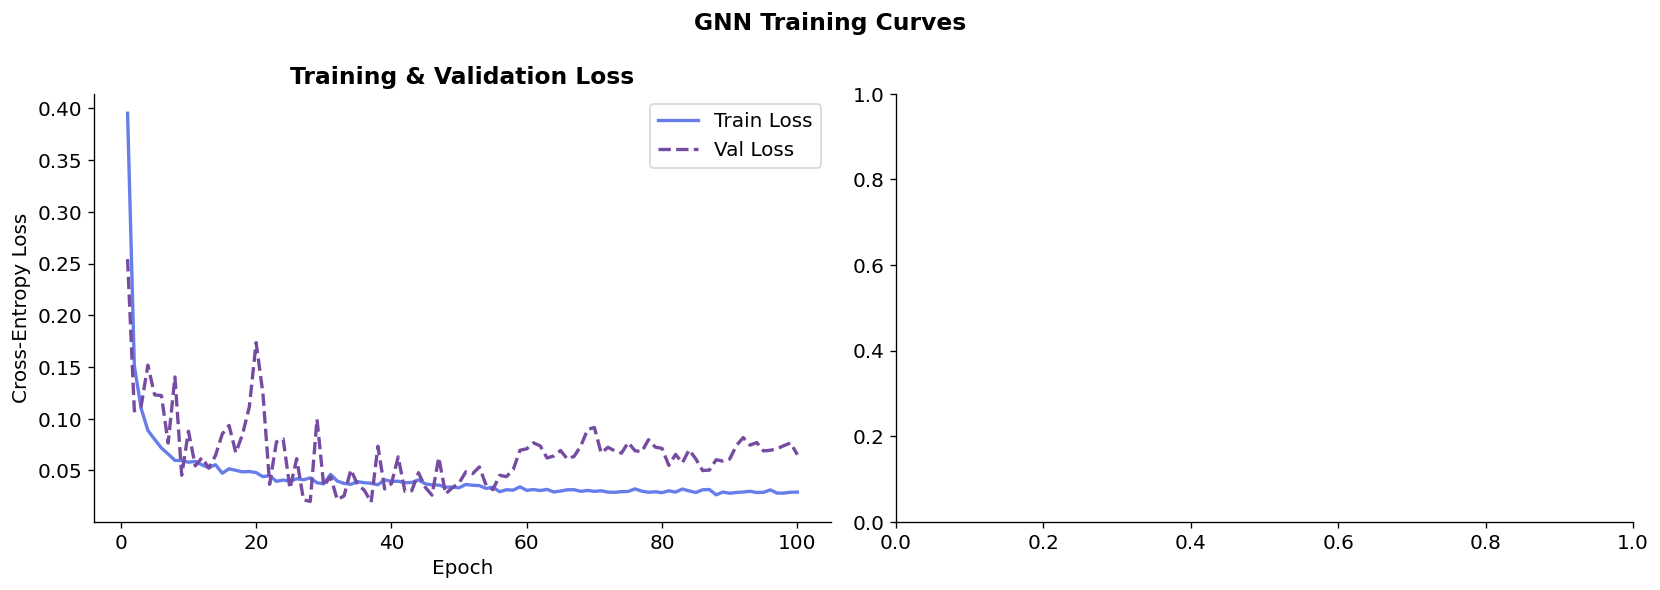

In [11]:
epochs_range = range(1, 101)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_range, gcn_history['train_loss'], color=PALETTE[0], lw=2, label='Train Loss')
axes[0].plot(epochs_range, gcn_history['val_loss'],   color=PALETTE[1], lw=2, ls='--', label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].legend()

# Loss
# axes[1].plot(epochs_range,gat_history['train_loss'], color=PALETTE[0], lw=2, label='Train Loss')
# axes[1].plot(epochs_range, gat_history['val_loss'],   color=PALETTE[1], lw=2, ls='--', label='Val Loss')
# axes[1].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
# axes[1].set_title('Training & Validation Loss', fontweight='bold')
# axes[1].legend()

# # Accuracy
# axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], color=PALETTE[0], lw=2, label='Train Acc')
# axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   color=PALETTE[1], lw=2, ls='--', label='Val Acc')
# axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
# axes[1].set_title('Training & Validation Accuracy', fontweight='bold')
# axes[1].legend()

plt.suptitle('GNN Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_03_training_curves.png', bbox_inches='tight')
plt.show()

NameError: name 'gat_history' is not defined

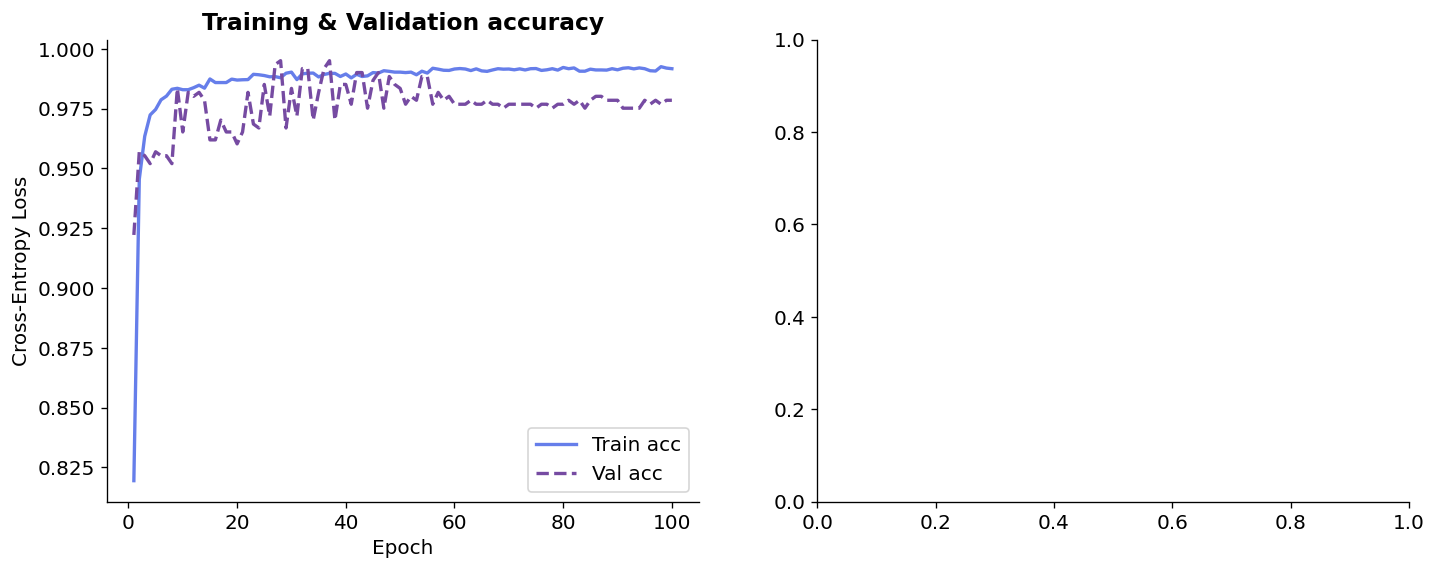

In [13]:
epochs_range = range(1, 100 + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_range, gcn_history['train_acc'], color=PALETTE[0], lw=2, label='Train acc')
axes[0].plot(epochs_range, gcn_history['val_acc'],   color=PALETTE[1], lw=2, ls='--', label='Val acc')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training & Validation accuracy', fontweight='bold')
axes[0].legend()

# Loss
axes[1].plot(epochs_range,gat_history['train_acc'], color=PALETTE[0], lw=2, label='Train acc')
axes[1].plot(epochs_range, gat_history['val_acc'],   color=PALETTE[1], lw=2, ls='--', label='Val acc')
axes[1].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[1].set_title('Training & Validation accuracy', fontweight='bold')
axes[1].legend()

# # Accuracy
# axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], color=PALETTE[0], lw=2, label='Train Acc')
# axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   color=PALETTE[1], lw=2, ls='--', label='Val Acc')
# axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
# axes[1].set_title('Training & Validation Accuracy', fontweight='bold')
# axes[1].legend()

plt.suptitle('GNN Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_03_training_curves.png', bbox_inches='tight')
plt.show()

In [14]:

# ── Save model weights ─────────────────────────────────────────────────────
import pickle

torch.save(gcn_model.state_dict(), 'bicep_curl_gcn.pth')
print('✅  Saved: bicep_curl_gcn.pth')

# ── Save the fitted scaler ─────────────────────────────────────────────────
with open('bicep_curl_gcn_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('✅  Saved: bicep_curl_gcn_scaler.pkl')

print()
print('These two files are all you need to run predictions.')
print('Use predict_bicep_curl.py to load and run inference.')


✅  Saved: bicep_curl_gcn.pth
✅  Saved: bicep_curl_gcn_scaler.pkl

These two files are all you need to run predictions.
Use predict_bicep_curl.py to load and run inference.


In [18]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.decomposition import PCA
import matplotlib.gridspec as gridspec

# ── Helper: run inference and collect all outputs ─────────────────────────
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    for batch in loader:
        batch  = batch.to(device)
        out    = model(batch)
        probs  = F.softmax(out, dim=1)[:, 1]
        pred   = out.argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
    return np.array(all_preds), np.array(all_probs), np.array(all_labels)


# ── Helper: compute all scalar metrics ────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'F1 Score' : f1_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall'   : recall_score(y_true, y_pred),
        'ROC-AUC'  : roc_auc_score(y_true, y_prob),
    }


# ── Run on test set ────────────────────────────────────────────────────────
gcn_preds, gcn_probs, gcn_true = collect_predictions(gcn_model, test_loader, DEVICE)
# gat_preds, gat_probs, gat_true = collect_predictions(gat_model, test_loader, DEVICE)

gcn_metrics = compute_metrics(gcn_true, gcn_preds, gcn_probs)
# gat_metrics = compute_metrics(gat_true, gat_preds, gat_probs)

EPOCHS = len(gcn_history['train_loss'])

print('GCN Test Metrics:')
for k, v in gcn_metrics.items():
    print(f'  {k:12s}: {v*100:.2f}%')
# print('\nGAT Test Metrics:')
# for k, v in gat_metrics.items():
#     print(f'  {k:12s}: {v*100:.2f}%')

GCN Test Metrics:
  Accuracy    : 99.50%
  F1 Score    : 99.43%
  Precision   : 99.62%
  Recall      : 99.25%
  ROC-AUC     : 99.98%


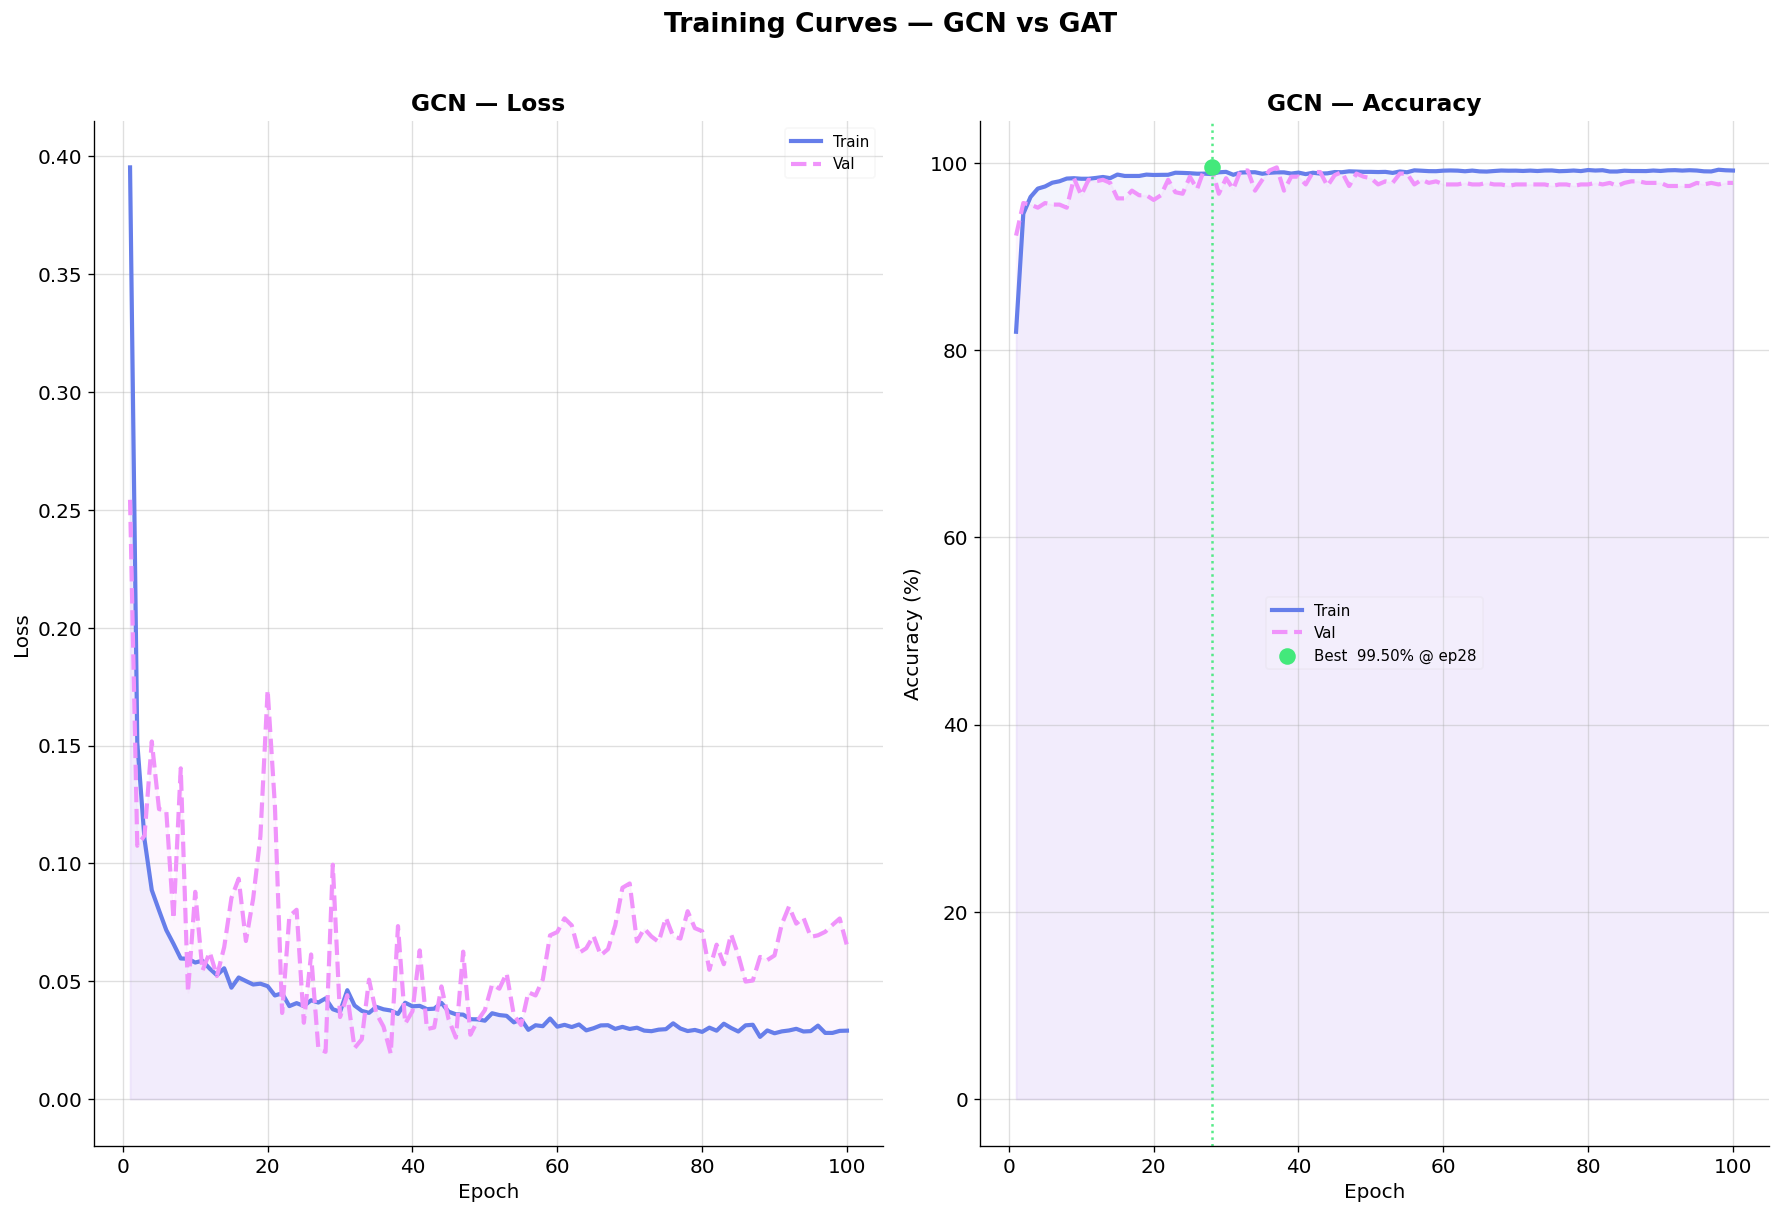

Saved: eval_01_training_curves.png


In [21]:
epochs_range = range(1, EPOCHS + 1)
C1, C2, C3, C4 = '#667eea', '#f093fb', '#4facfe', '#43e97b'

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.suptitle('Training Curves — GCN vs GAT', fontsize=16, fontweight='bold', y=1.01)

titles = ['GCN — Loss','GCN — Accuracy']
configs = [
    (gcn_history['train_loss'], gcn_history['val_loss'],  'Loss',         False),
    #(gat_history['train_loss'], gat_history['val_loss'],  'Loss',         False),
    (gcn_history['train_acc'],  gcn_history['val_acc'],   'Accuracy (%)', True),
    #(gat_history['train_acc'],  gat_history['val_acc'],   'Accuracy (%)', True),
]

for ax, title, (train_vals, val_vals, ylabel, is_acc) in zip(
        axes.flatten(), titles, configs):

    if is_acc:
        train_vals = [v * 100 for v in train_vals]
        val_vals   = [v * 100 for v in val_vals]

    ax.plot(epochs_range, train_vals, color=C1, lw=2.5, label='Train')
    ax.plot(epochs_range, val_vals,   color=C2, lw=2.5, ls='--', label='Val')
    ax.fill_between(epochs_range, train_vals, alpha=0.08, color=C1)
    ax.fill_between(epochs_range, val_vals,   alpha=0.08, color=C2)

    if is_acc:
        best_ep  = int(np.argmax(val_vals)) + 1
        best_val = max(val_vals)
        ax.axvline(best_ep, color=C4, lw=1.5, ls=':', alpha=0.9)
        ax.scatter(best_ep, best_val, color=C4, s=80, zorder=5,
                   label=f'Best  {best_val:.2f}% @ ep{best_ep}')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9, framealpha=0.15)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('eval_01_training_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: eval_01_training_curves.png')

GCN: TN=338  FP=1  FN=2  TP=263  | Acc=99.50%


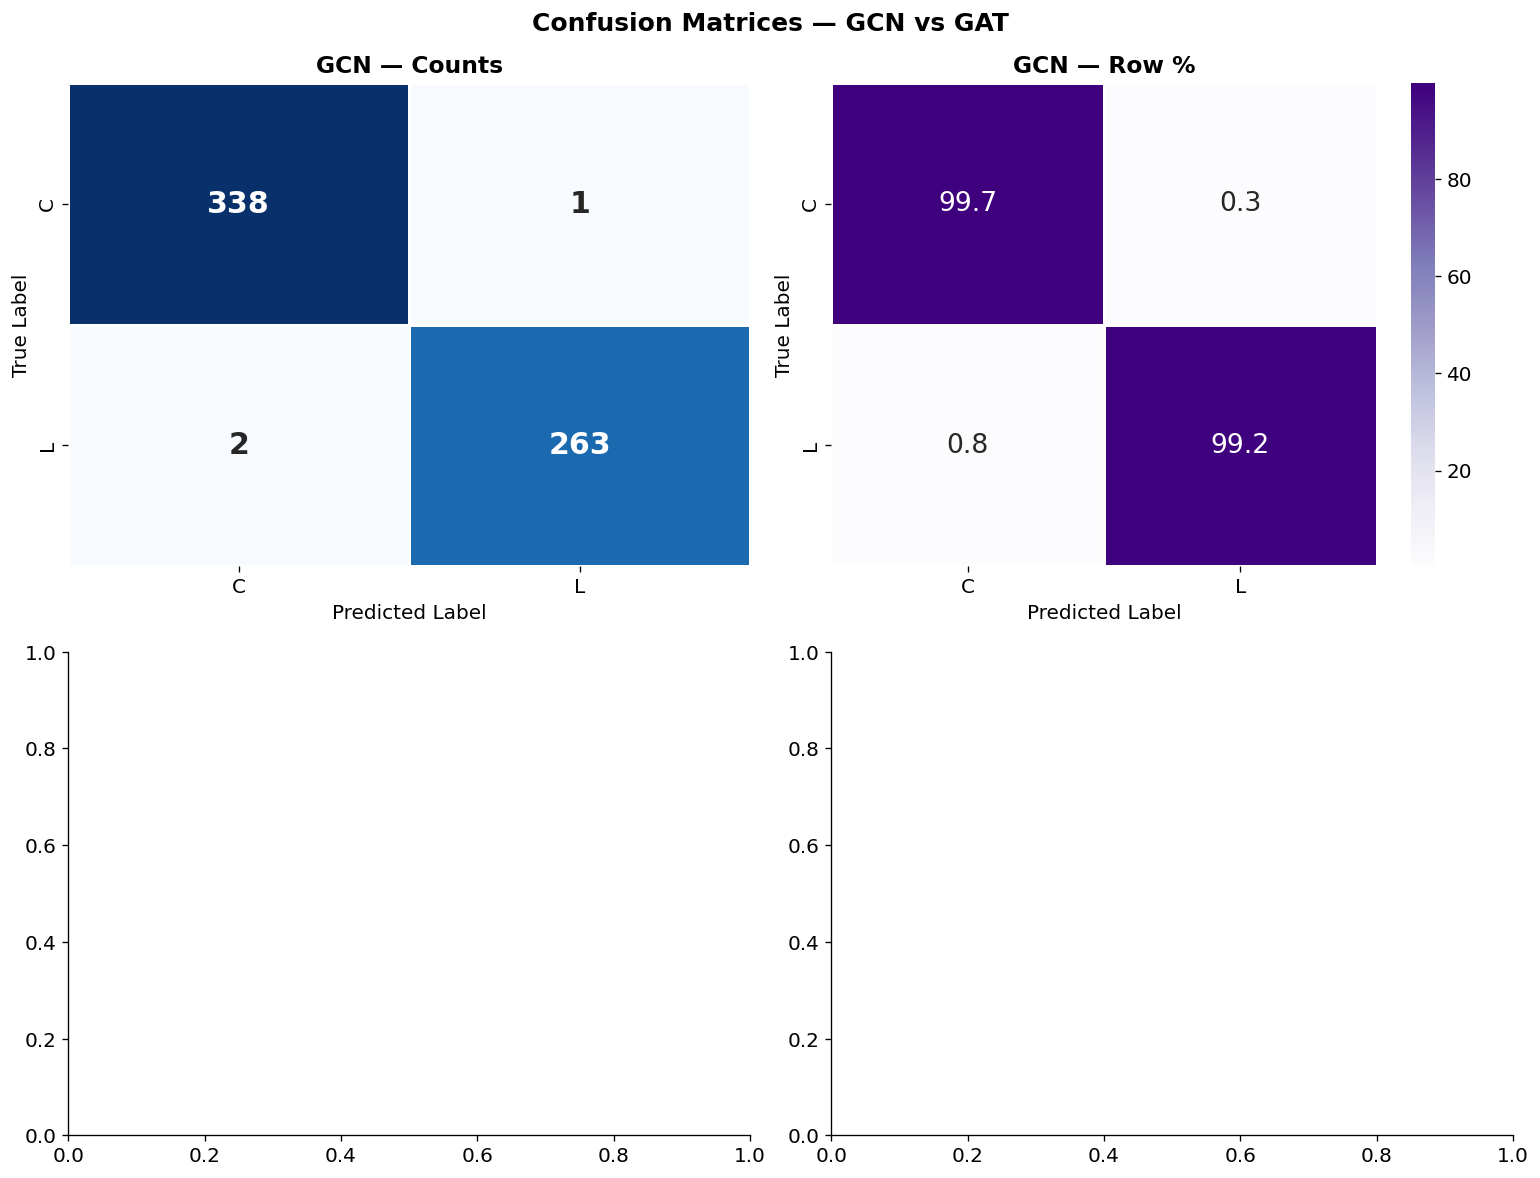

Saved: eval_02_confusion_matrices.png


In [26]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Confusion Matrices — GCN vs GAT', fontsize=15, fontweight='bold')

class_names = le.classes_   # ['C', 'L']

for row, (name, preds, true) in enumerate([
    ('GCN', gcn_preds, gcn_true)
]):
    cm     = confusion_matrix(true, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=1.5, ax=axes[row][0], cbar=False,
                annot_kws={'size': 18, 'weight': 'bold'})
    axes[row][0].set_title(f'{name} — Counts', fontweight='bold')
    axes[row][0].set_xlabel('Predicted Label')
    axes[row][0].set_ylabel('True Label')

    # Percentages
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Purples',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=1.5, ax=axes[row][1], cbar=True,
                annot_kws={'size': 16})
    axes[row][1].set_title(f'{name} — Row %', fontweight='bold')
    axes[row][1].set_xlabel('Predicted Label')
    axes[row][1].set_ylabel('True Label')

    # Print stats
    tn, fp, fn, tp = cm.ravel()
    print(f'{name}: TN={tn}  FP={fp}  FN={fn}  TP={tp}  '
          f'| Acc={accuracy_score(true,preds)*100:.2f}%')

plt.tight_layout()
plt.savefig('eval_02_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: eval_02_confusion_matrices.png')

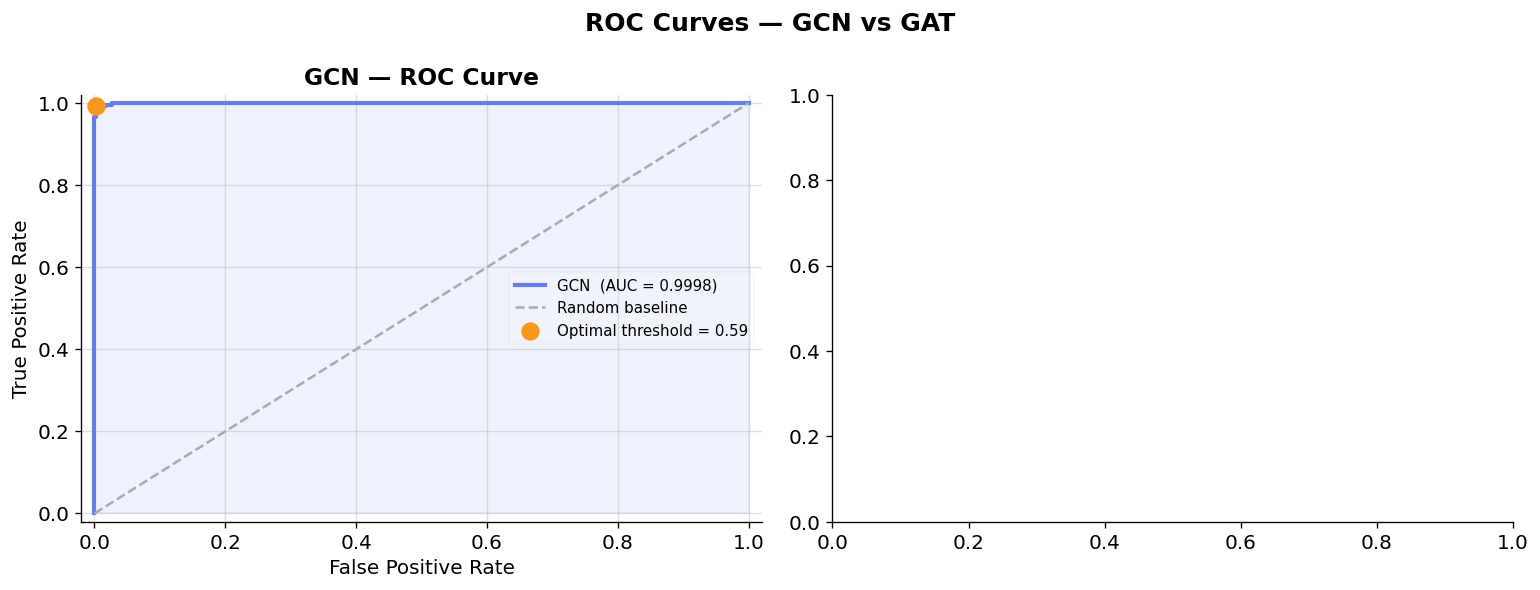

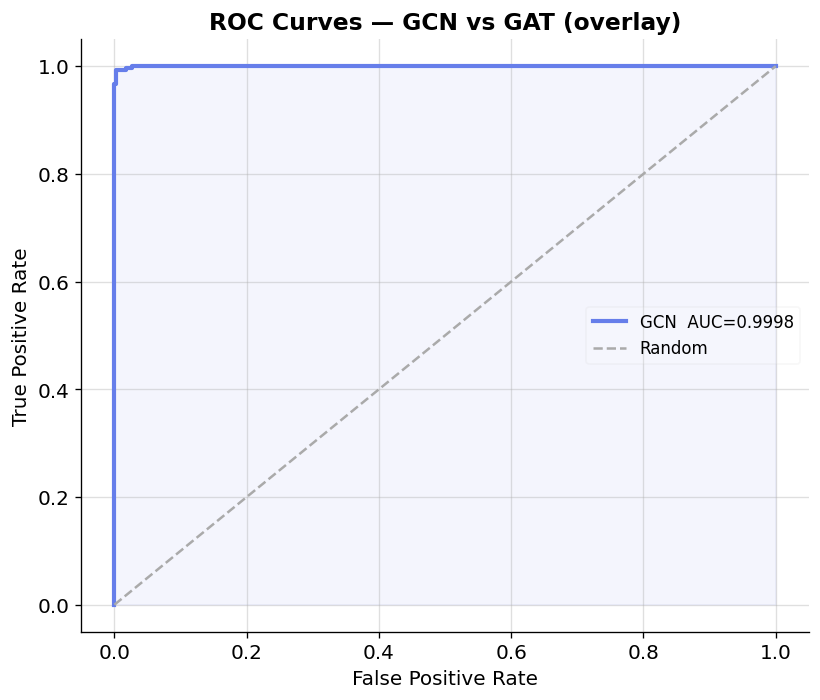

Saved: eval_03_roc_curves.png | eval_04_roc_overlay.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ROC Curves — GCN vs GAT', fontsize=15, fontweight='bold')

# Individual ROC plots
for ax, (name, probs, true, color) in zip(axes, [
    ('GCN', gcn_probs, gcn_true, C1),
]):
    fpr, tpr, thresholds = roc_curve(true, probs)
    auc_val = roc_auc_score(true, probs)

    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name}  (AUC = {auc_val:.4f})')
    ax.plot([0, 1], [0, 1], '--', color='#aaa', lw=1.5, label='Random baseline')
    ax.fill_between(fpr, tpr, alpha=0.10, color=color)

    # Mark optimal threshold (Youden's J)
    j_scores  = tpr - fpr
    opt_idx   = np.argmax(j_scores)
    opt_thr   = thresholds[opt_idx]
    ax.scatter(fpr[opt_idx], tpr[opt_idx], color='#f7971e', s=100, zorder=5,
               label=f'Optimal threshold = {opt_thr:.2f}')

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{name} — ROC Curve', fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.15)
    ax.grid(True, alpha=0.4)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig('eval_03_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

# Combined overlay
fig, ax = plt.subplots(figsize=(7, 6))
for name, probs, true, color, ls in [
    ('GCN', gcn_probs, gcn_true, C1, '-'),

]:
    fpr, tpr, _ = roc_curve(true, probs)
    auc_val     = roc_auc_score(true, probs)
    ax.plot(fpr, tpr, color=color, lw=2.5, ls=ls, label=f'{name}  AUC={auc_val:.4f}')
    ax.fill_between(fpr, tpr, alpha=0.07, color=color)

ax.plot([0, 1], [0, 1], '--', color='#aaa', lw=1.5, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — GCN vs GAT (overlay)', fontweight='bold')
ax.legend(fontsize=10, framealpha=0.15)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('eval_04_roc_overlay.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: eval_03_roc_curves.png | eval_04_roc_overlay.png')

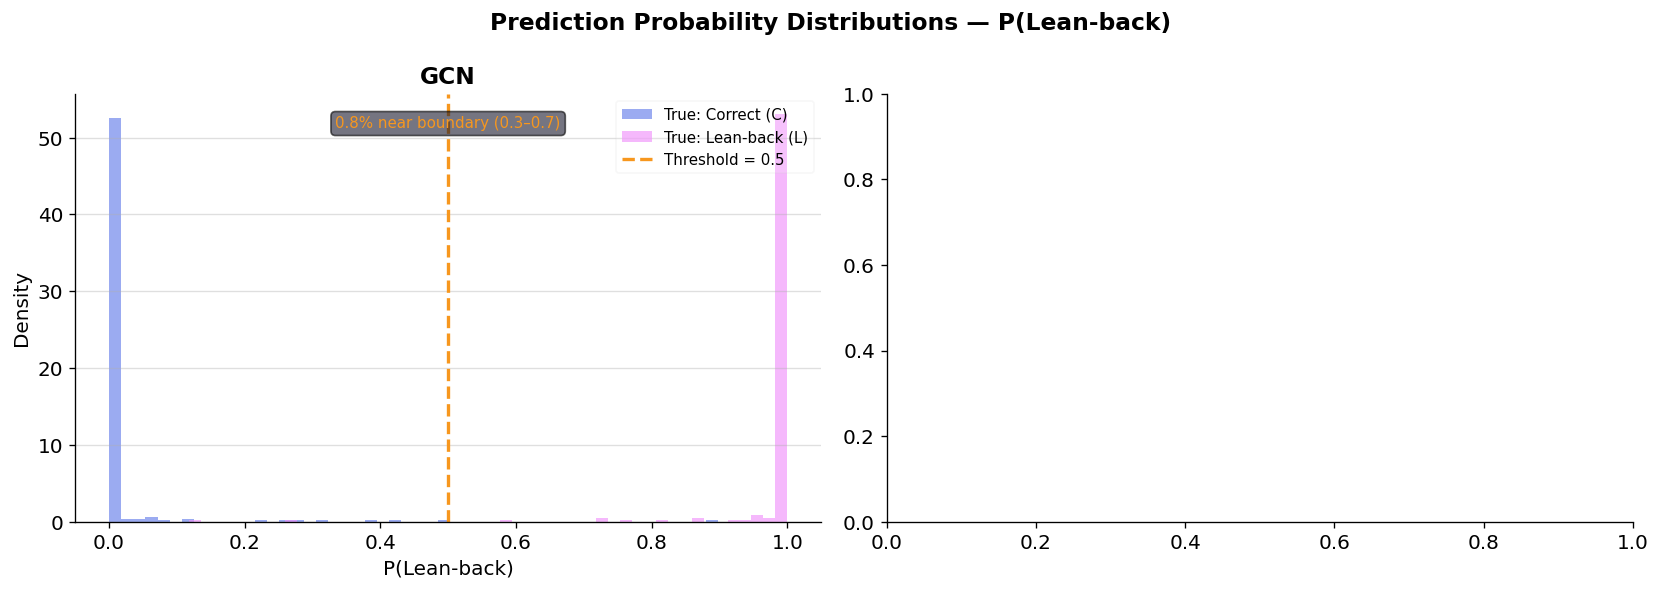

Saved: eval_05_prob_distributions.png


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prediction Probability Distributions — P(Lean-back)',
             fontsize=14, fontweight='bold')

for ax, (name, probs, true) in zip(axes, [
    ('GCN', gcn_probs, gcn_true),
]):
    for lv, color, label in [
        (0, C1, 'True: Correct (C)'),
        (1, C2, 'True: Lean-back (L)'),
    ]:
        ax.hist(probs[true == lv], bins=50, alpha=0.65, color=color,
                label=label, edgecolor='none', density=True)

    ax.axvline(0.5, color='#f7971e', lw=2, ls='--', label='Threshold = 0.5')
    ax.set_xlabel('P(Lean-back)')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}', fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.15)
    ax.grid(axis='y', alpha=0.4)

    # Annotation: % near boundary
    near_boundary = ((probs > 0.3) & (probs < 0.7)).mean() * 100
    ax.text(0.5, ax.get_ylim()[1] * 0.92,
            f'{near_boundary:.1f}% near boundary (0.3–0.7)',
            ha='center', fontsize=9, color='#f7971e',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a1a2e', alpha=0.6))

plt.tight_layout()
plt.savefig('eval_05_prob_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: eval_05_prob_distributions.png')

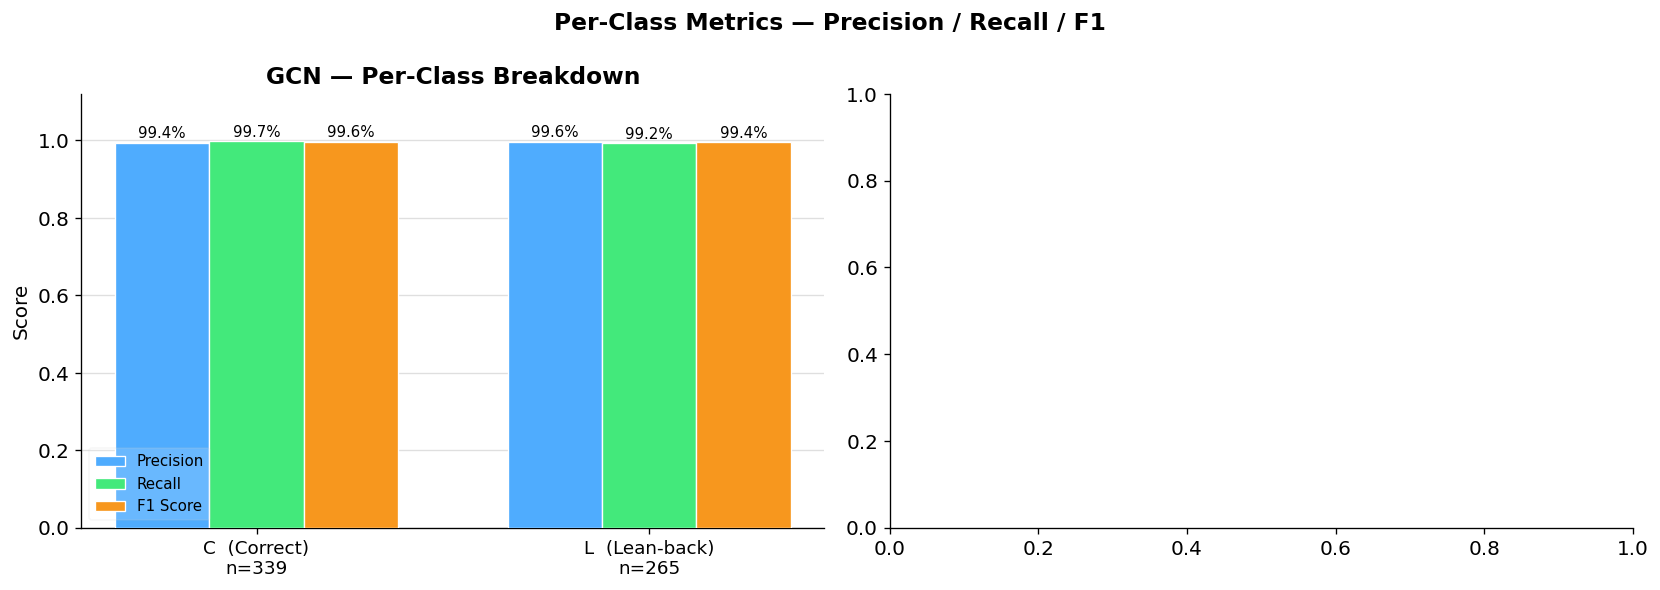


── GCN Classification Report ──
               precision    recall  f1-score   support

  C (Correct)       0.99      1.00      1.00       339
L (Lean-back)       1.00      0.99      0.99       265

     accuracy                           1.00       604
    macro avg       1.00      0.99      0.99       604
 weighted avg       1.00      1.00      1.00       604

Saved: eval_07_per_class_metrics.png


In [31]:
from sklearn.metrics import precision_recall_fscore_support

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Per-Class Metrics — Precision / Recall / F1',
             fontsize=14, fontweight='bold')

for ax, (name, preds, true) in zip(axes, [
    ('GCN', gcn_preds, gcn_true),
]):
    prec, rec, f1, support = precision_recall_fscore_support(
        true, preds, labels=[0, 1])

    x       = np.arange(2)        # C, L
    w       = 0.24
    colors  = ['#4facfe', '#43e97b', '#f7971e']

    bars_p = ax.bar(x - w,     prec, w, color=colors[0], edgecolor='white',
                    linewidth=0.8, label='Precision', zorder=3)
    bars_r = ax.bar(x,         rec,  w, color=colors[1], edgecolor='white',
                    linewidth=0.8, label='Recall',    zorder=3)
    bars_f = ax.bar(x + w,     f1,   w, color=colors[2], edgecolor='white',
                    linewidth=0.8, label='F1 Score',  zorder=3)

    for bars in [bars_p, bars_r, bars_f]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f'{bar.get_height()*100:.1f}%',
                    ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(['C  (Correct)\n' + f'n={support[0]}',
                        'L  (Lean-back)\n' + f'n={support[1]}'],
                       fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Score')
    ax.set_title(f'{name} — Per-Class Breakdown', fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.15)
    ax.grid(axis='y', alpha=0.4, zorder=0)

plt.tight_layout()
plt.savefig('eval_07_per_class_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

# Print full classification reports
for name, preds, true in [('GCN', gcn_preds, gcn_true)]:
    print(f'\n── {name} Classification Report ──')
    print(classification_report(true, preds, target_names=['C (Correct)', 'L (Lean-back)']))

print('Saved: eval_07_per_class_metrics.png')

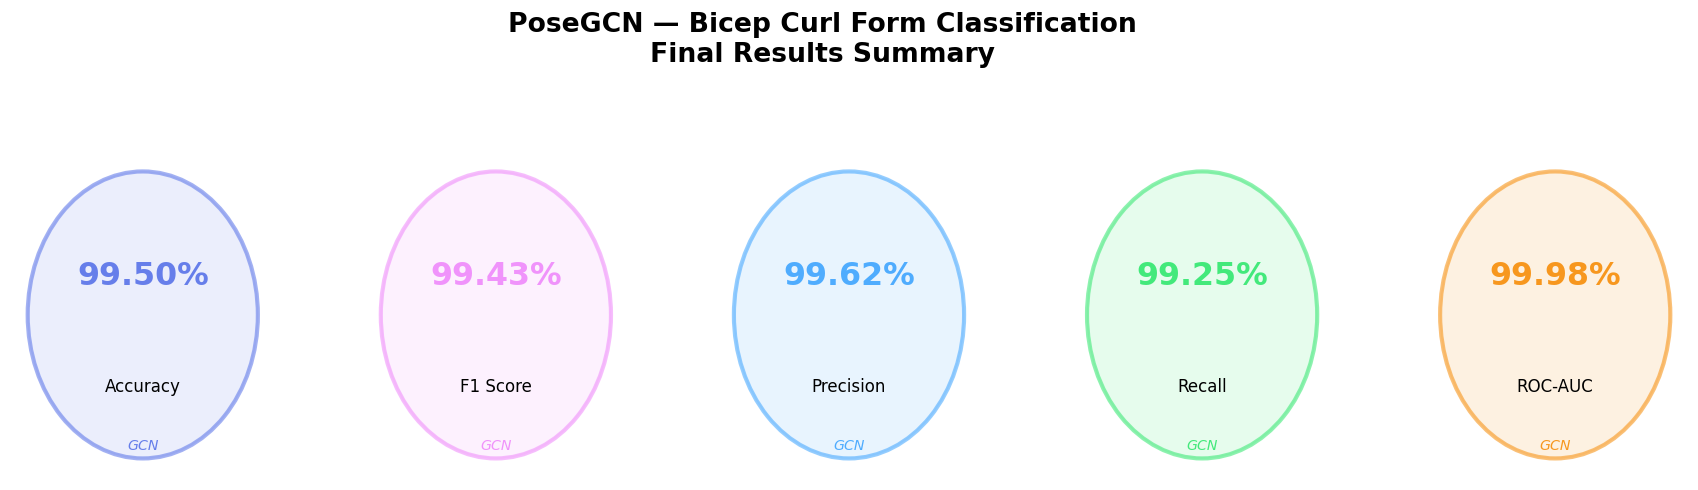


════════════════════════════════════════════════════
  Metric                   GCN           GAT  Winner
────────────────────────────────────────────────────


NameError: name 'gat_metrics' is not defined

In [32]:
metric_names  = ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC-AUC']
accent_colors = [C1, C2, C3, C4, '#f7971e']

fig = plt.figure(figsize=(18, 9))
fig.suptitle('PoseGCN — Bicep Curl Form Classification\nFinal Results Summary',
             fontsize=16, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.55, wspace=0.35)

# ── Top row: GCN metric circles ────────────────────────────────────────────
for col, (metric, color) in enumerate(zip(metric_names, accent_colors)):
    ax = fig.add_subplot(gs[0, col])
    val = gcn_metrics[metric]
    ax.add_patch(plt.Circle((0.5, 0.5), 0.44, color=color, alpha=0.13))
    ax.add_patch(plt.Circle((0.5, 0.5), 0.44, fill=False,
                             edgecolor=color, linewidth=2.5, alpha=0.6))
    ax.text(0.5, 0.62, f'{val*100:.2f}%',
            ha='center', va='center', fontsize=19,
            fontweight='bold', color=color)
    ax.text(0.5, 0.28, metric,
            ha='center', va='center', fontsize=10)
    ax.text(0.5, 0.10, 'GCN',
            ha='center', va='center', fontsize=8.5,
            color=color, fontstyle='italic')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

# ── Bottom row: GAT metric circles ─────────────────────────────────────────
# for col, (metric, color) in enumerate(zip(metric_names, accent_colors)):
#     ax = fig.add_subplot(gs[1, col])
#     val = gat_metrics[metric]
#     ax.add_patch(plt.Circle((0.5, 0.5), 0.44, color=color, alpha=0.08))
#     ax.add_patch(plt.Circle((0.5, 0.5), 0.44, fill=False,
#                              edgecolor=color, linewidth=2, alpha=0.4,
#                              linestyle='--'))
#     ax.text(0.5, 0.62, f'{val*100:.2f}%',
#             ha='center', va='center', fontsize=19,
#             fontweight='bold', color=color, alpha=0.85)
#     ax.text(0.5, 0.28, metric,
#             ha='center', va='center', fontsize=10)
#     ax.text(0.5, 0.10, 'GAT',
#             ha='center', va='center', fontsize=8.5,
#             color=color, fontstyle='italic', alpha=0.85)
#     ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

plt.savefig('eval_09_final_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Final summary table ────────────────────────────────────────────────────
print('\n' + '═'*52)
print(f'  {"Metric":14s}  {"GCN":>12}  {"GAT":>12}  {"Winner":>6}')
print('─'*52)
for m in metric_names:
    g = gcn_metrics[m]
    a = gat_metrics[m]
    winner = 'GCN' if g >= a else 'GAT'
    marker = '✓' if g >= a else ' '
    print(f'  {m:14s}  {g*100:>11.2f}%  {a*100:>11.2f}%  {winner:>6}')
print('═'*52)
print('Saved: eval_09_final_dashboard.png')